# Brake Pad Multiobjective Optimization: Pareto Front

This notebook combines the braking-torque and maximum-equivalent-stress surrogate models to identify nondominated brake-pad designs. The Pareto search minimizes **MaxEquivStress** while maximizing **BrakingTorque** over the observed design bounds.

In [7]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, NonlinearConstraint
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

# Load the same three material datasets used by BrakePadOptm and BrakePadOptm2.
def load_dataset(filename, percentage):
    frame = pd.read_csv(filename, comment='#')
    frame = frame.drop(columns=['P10', 'P11', 'P14', 'P15'])
    frame = frame.rename(columns={
        'Name': 'percentage',
        'P1': 'InnerDiameter',
        'P7': 'ActuationForce',
        'P9': 'SweepAngle',
        'P5': 'MaxEquivStress',
        'P6': 'MaxEquivPlastStrain',
        'P16': 'BrakingTorque',
    })
    frame['percentage'] = float(percentage)
    frame['SweepAngle'] = 180.0 - 2.0 * frame['SweepAngle']
    return frame


data = pd.concat([
    load_dataset('FivePercentCocopeat.csv', 5),
    load_dataset('TenPercentCocopeat.csv', 10),
    load_dataset('FifteenPercentCocopeat.csv', 15),
], ignore_index=True)

features = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
X = data[features]
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

print(f'Loaded {len(data)} design points with {len(features)} shared input features.')

Loaded 45 design points with 4 shared input features.


In [8]:
# Use anisotropic Matern kernels with WhiteKernel noise for all three responses.
def fit_surrogate(target):
    kernel = C(1.0, (1e-5, 1e5)) * Matern(
        length_scale=np.ones(len(features)),
        length_scale_bounds=(1e-2, 1e3),
        nu=2.5,
    ) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2))
    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=15,
        alpha=1e-3,
        normalize_y=True,
        random_state=42,
    )
    model.fit(X_scaled, target)
    return model

# Log-transform stress because its measured values are positive and right-skewed.
stress_model = fit_surrogate(np.log1p(data['MaxEquivStress']))
torque_model = fit_surrogate(data['BrakingTorque'])
plastic_strain_model = fit_surrogate(data['MaxEquivPlastStrain'])

predicted_stress = np.expm1(stress_model.predict(X_scaled))
predicted_torque = torque_model.predict(X_scaled)
predicted_plastic_strain = plastic_strain_model.predict(X_scaled)
print('Stress, torque, and plastic-strain surrogate models fitted successfully.')
print(f'Stress training R2: {1 - np.sum((data["MaxEquivStress"] - predicted_stress) ** 2) / np.sum((data["MaxEquivStress"] - data["MaxEquivStress"].mean()) ** 2):.4f}')
print(f'Torque training R2: {1 - np.sum((data["BrakingTorque"] - predicted_torque) ** 2) / np.sum((data["BrakingTorque"] - data["BrakingTorque"].mean()) ** 2):.4f}')
print(f'Plastic-strain training R2: {1 - np.sum((data["MaxEquivPlastStrain"] - predicted_plastic_strain) ** 2) / np.sum((data["MaxEquivPlastStrain"] - data["MaxEquivPlastStrain"].mean()) ** 2):.4f}')

/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Stress, torque, and plastic-strain surrogate models fitted successfully.
Stress training R2: 1.0000
Torque training R2: 0.9999
Plastic-strain training R2: 1.0000


/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
# Minimize normalized stress and maximize normalized torque for many trade-off weights.
bounds = [(X[feature].min(), X[feature].max()) for feature in features]
stress_min = float(data['MaxEquivStress'].min())
stress_max = float(data['MaxEquivStress'].max())
torque_min = float(data['BrakingTorque'].min())
torque_max = float(data['BrakingTorque'].max())


def predict_objectives(values):
    candidate = pd.DataFrame([values], columns=features)
    candidate_scaled = scaler_X.transform(candidate)
    stress = float(np.expm1(stress_model.predict(candidate_scaled)[0]))
    torque = float(torque_model.predict(candidate_scaled)[0])
    plastic_strain = float(plastic_strain_model.predict(candidate_scaled)[0])
    return stress, torque, plastic_strain


def plastic_strain_constraint(values):
    """Feasible candidates satisfy predicted MaxEquivPlastStrain <= 0."""
    return predict_objectives(values)[2]


def scalarized_objective(values, stress_weight):
    stress, torque, _ = predict_objectives(values)
    normalized_stress = (stress - stress_min) / (stress_max - stress_min)
    normalized_torque = (torque_max - torque) / (torque_max - torque_min)
    return stress_weight * normalized_stress + (1.0 - stress_weight) * normalized_torque


tradeoff_weights = np.linspace(0.0, 1.0, 31)
plastic_constraint = NonlinearConstraint(plastic_strain_constraint, -np.inf, 0.0)
solutions = []
for stress_weight in tradeoff_weights:
    result = differential_evolution(
        lambda values: scalarized_objective(values, stress_weight),
        bounds=bounds,
        constraints=(plastic_constraint,),
        seed=42,
        polish=True,
        maxiter=150,
        popsize=12,
    )
    stress, torque, plastic_strain = predict_objectives(result.x)
    solutions.append({
        'Stress Weight': stress_weight,
        **dict(zip(features, result.x)),
        'Predicted MaxEquivStress': stress,
        'Predicted BrakingTorque': torque,
        'Predicted MaxEquivPlastStrain': plastic_strain,
        'Optimization Successful': result.success,
    })

solutions = pd.DataFrame(solutions)

# Keep a point when no other feasible point is at least as good in both objectives.
def pareto_mask(frame):
    objective_values = frame[['Predicted MaxEquivStress', 'Predicted BrakingTorque']].to_numpy()
    is_dominated = np.zeros(len(frame), dtype=bool)
    for index, point in enumerate(objective_values):
        no_worse = (objective_values[:, 0] <= point[0]) & (objective_values[:, 1] >= point[1])
        strictly_better = (objective_values[:, 0] < point[0]) | (objective_values[:, 1] > point[1])
        is_dominated[index] = np.any(no_worse & strictly_better)
    return ~is_dominated


pareto_front = solutions.loc[pareto_mask(solutions)].sort_values('Predicted MaxEquivStress').reset_index(drop=True)
print(f'Found {len(pareto_front)} feasible nondominated surrogate designs.')
print(f'Maximum predicted plastic strain on Pareto front: {pareto_front["Predicted MaxEquivPlastStrain"].max():.3e}')
display(pareto_front.round(3))

/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining th

Found 16 feasible nondominated surrogate designs.
Maximum predicted plastic strain on Pareto front: -5.268e-11


,Stress Weight,percentage,InnerDiameter,ActuationForce,SweepAngle,Predicted MaxEquivStress,Predicted BrakingTorque,Predicted MaxEquivPlastStrain,Optimization Successful
0,0.833,14.997,125.500,-13442.220,81.756,3.722,928.296,-0.0,True
1,0.800,15.000,125.500,-13924.447,81.598,3.820,960.456,-0.0,True
2,0.733,9.997,125.506,-14363.703,83.001,4.421,996.717,-0.0,True
3,0.700,10.000,125.500,-14812.444,83.275,4.597,1029.074,-0.0,True
4,0.667,10.001,125.504,-15335.723,84.110,4.863,1069.648,-0.0,True
5,0.633,10.000,125.553,-15371.522,84.110,4.879,1071.529,-0.0,True
6,0.567,10.000,125.506,-19661.250,81.840,6.032,1347.811,-0.0,True
7,0.533,9.998,125.500,-19666.667,81.870,6.034,1348.431,-0.0,True
8,0.467,9.999,125.510,-19664.976,82.305,6.066,1350.795,-0.0,True
9,0.367,10.001,125.514,-19666.573,82.312,6.068,1350.888,-0.0,True


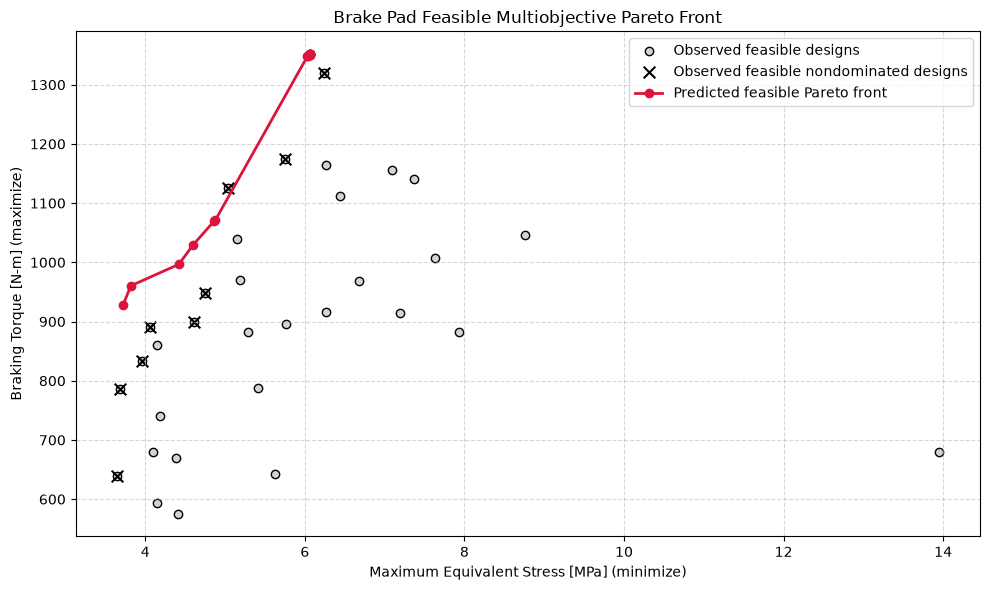

Balanced feasible compromise design


,Stress Weight,percentage,InnerDiameter,ActuationForce,SweepAngle,Predicted MaxEquivStress,Predicted BrakingTorque,Predicted MaxEquivPlastStrain,Optimization Successful
15,0.5,10.0,125.5,-19666.666,82.353,6.069,1351.356,-0.0,True


In [10]:
# Compare the feasible surrogate Pareto front with feasible observed designs.
feasible_data = data[data['MaxEquivPlastStrain'] <= 0].copy()
observed_front = feasible_data.loc[
    pareto_mask(pd.DataFrame({
        'Predicted MaxEquivStress': feasible_data['MaxEquivStress'],
        'Predicted BrakingTorque': feasible_data['BrakingTorque'],
    }))
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    feasible_data['MaxEquivStress'],
    feasible_data['BrakingTorque'],
    color='lightgray',
    edgecolor='black',
    label='Observed feasible designs',
)
plt.scatter(
    observed_front['MaxEquivStress'],
    observed_front['BrakingTorque'],
    color='black',
    marker='x',
    s=70,
    label='Observed feasible nondominated designs',
)
plt.plot(
    pareto_front['Predicted MaxEquivStress'],
    pareto_front['Predicted BrakingTorque'],
    color='crimson',
    marker='o',
    linewidth=2,
    label='Predicted feasible Pareto front',
)
plt.xlabel('Maximum Equivalent Stress [MPa] (minimize)')
plt.ylabel('Braking Torque [N-m] (maximize)')
plt.title('Brake Pad Feasible Multiobjective Pareto Front')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Select a balanced feasible compromise using equal normalized weights.
balanced_design = solutions.iloc[(solutions['Stress Weight'] - 0.5).abs().argmin()]
print('Balanced feasible compromise design')
display(pd.DataFrame([balanced_design]).round(3))